# Section 2. Stochastic portfolio theory and a stochastic diversity–dispersion model

## 0. Packages and Variables

In [1]:
import os

import _paths  # noqa: F401
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from config import CONFIG, DT_DAILY, DT_MONTHLY
from paths import DATA, FIGURES, relative_path
from plotting import plot_dispersion
from plotting import use_paper_style as ups
from utils import calibrate_c_delta

In [2]:
width, height = ups(usetex=True)

In [3]:
START_DATE, WARMUP_END_DATE = CONFIG["backtest_config"]["warmup_dates"]
START_DATE, WARMUP_END_DATE

('1977-01-01', '1994-12-31')

## 1. Data

In [4]:
signals = pd.read_csv(
    f"{DATA}/processed/signals_1977.csv", index_col=0, parse_dates=True
)
signals_clean = pd.read_csv(
    f"{DATA}/processed/signals_clean_1977.csv", index_col=0, parse_dates=True
)
signals.head()

,diversity,rd_eql,rd_mkt,dispersion
date,,,,
1977-01-03,-7.131184,0.061520,0.024566,0.012869
1977-01-04,-7.128770,0.059674,0.027883,0.012483
1977-01-05,-7.130464,0.065707,0.033798,0.013745
1977-01-06,-7.128295,0.058780,0.029815,0.012296
1977-01-07,-7.126940,0.052622,0.024160,0.011008


In [5]:
monthly_rets = pd.read_csv(
    f"{DATA}/processed/rets_monthly_1977.csv", index_col=0, parse_dates=True
)
monthly_caps = pd.read_csv(
    f"{DATA}/processed/caps_monthly_1977.csv", index_col=0, parse_dates=True
)
monthly_mkt_wgts = pd.read_csv(
    f"{DATA}/processed/mkt_wgts_monthly_1977.csv", index_col=0, parse_dates=True
)
monthly_eql_wgts = pd.read_csv(
    f"{DATA}/processed/eql_wgts_monthly_1977.csv", index_col=0, parse_dates=True
)

In [6]:
dspx = pd.read_csv(
    f"{DATA}/external/DSPX_2014.csv", parse_dates=["Date"], index_col=0
).squeeze()

## 2. Plotting diversity and realized dispersion

Saved figure to ./figures/diversity.pdf


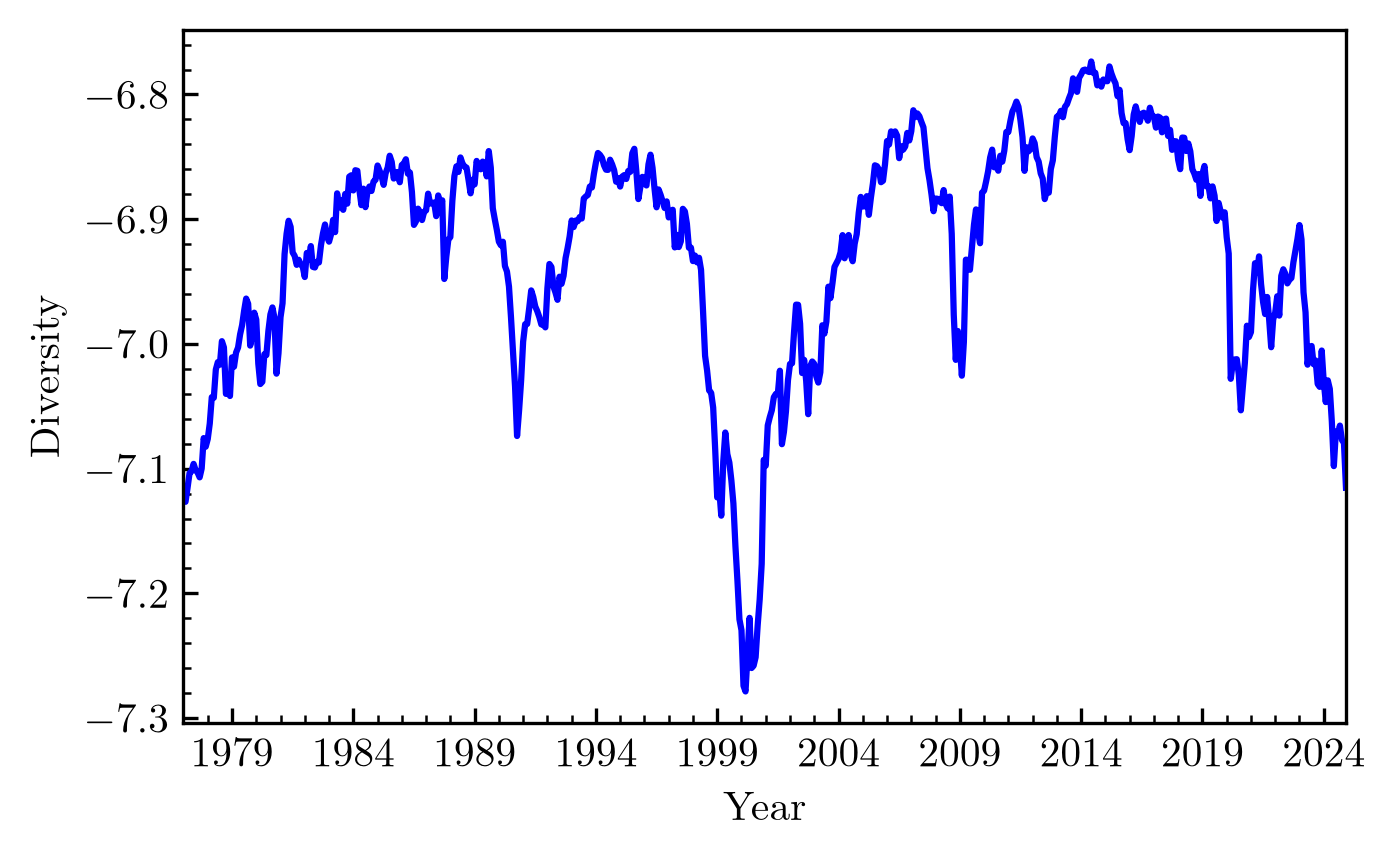

In [7]:
# Plot monthly diversity
fig, ax = plt.subplots(figsize=(width, height))

diversity_monthly = signals["diversity"].resample("ME").last()
diversity_monthly.plot(ax=ax, color="b")
ax.set_xlabel("Year")
ax.set_ylabel("Diversity")
os.makedirs(FIGURES, exist_ok=True)
save_path = f"{FIGURES}/diversity.pdf"
plt.savefig(save_path, format="pdf", dpi=600)
print(f"Saved figure to {relative_path(save_path)}")

Saved figure to ./figures/dispersion.pdf


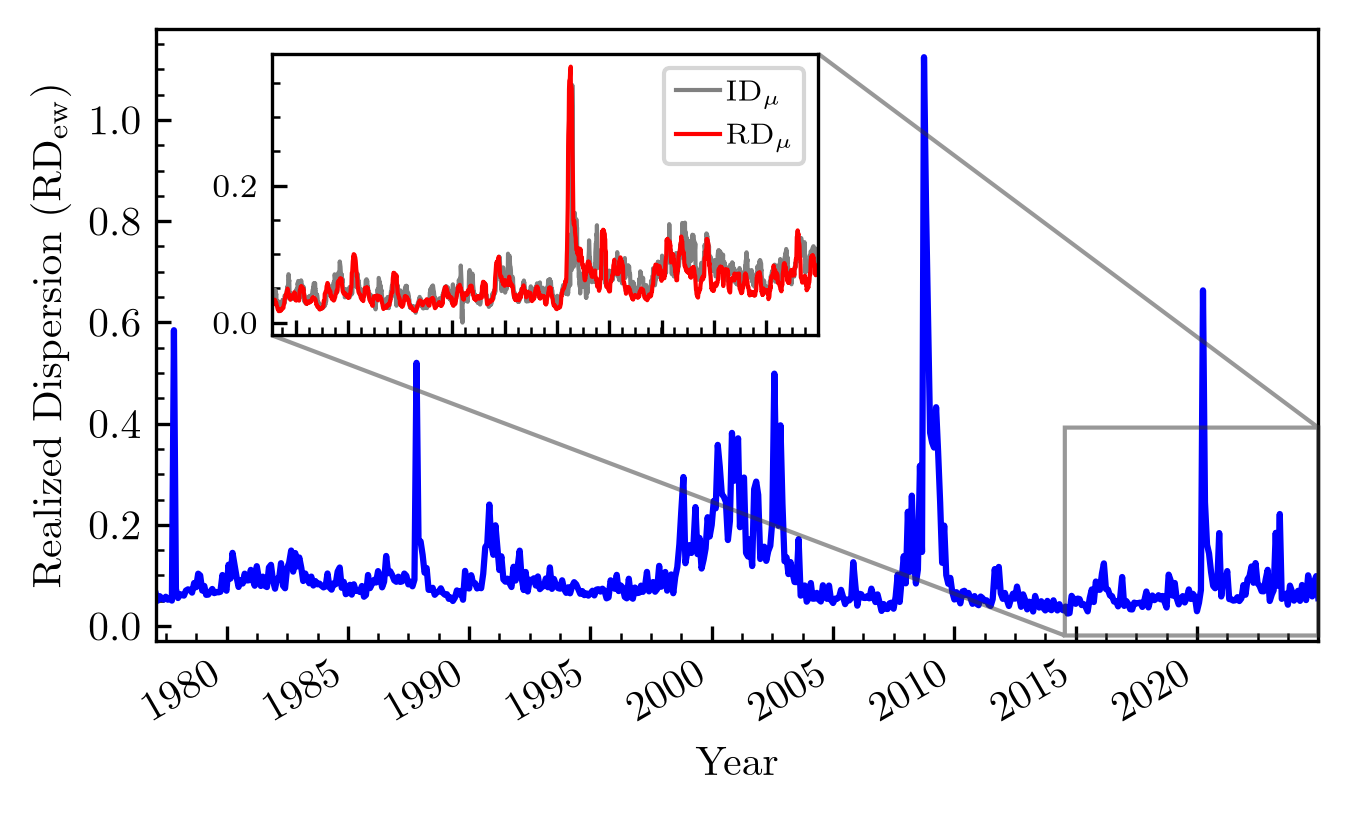

In [8]:
# Plot monthly realized dispersion
plot_dispersion(signals, dspx, save_fig=True)

## 3. Computing $c_\delta$

Regression summary:
                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.952
Model:                            OLS   Adj. R-squared (uncentered):              0.952
Method:                 Least Squares   F-statistic:                              4265.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):                   2.64e-143
Time:                        12:04:28   Log-Likelihood:                          508.95
No. Observations:                 215   AIC:                                     -1016.
Df Residuals:                     214   BIC:                                     -1013.
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------

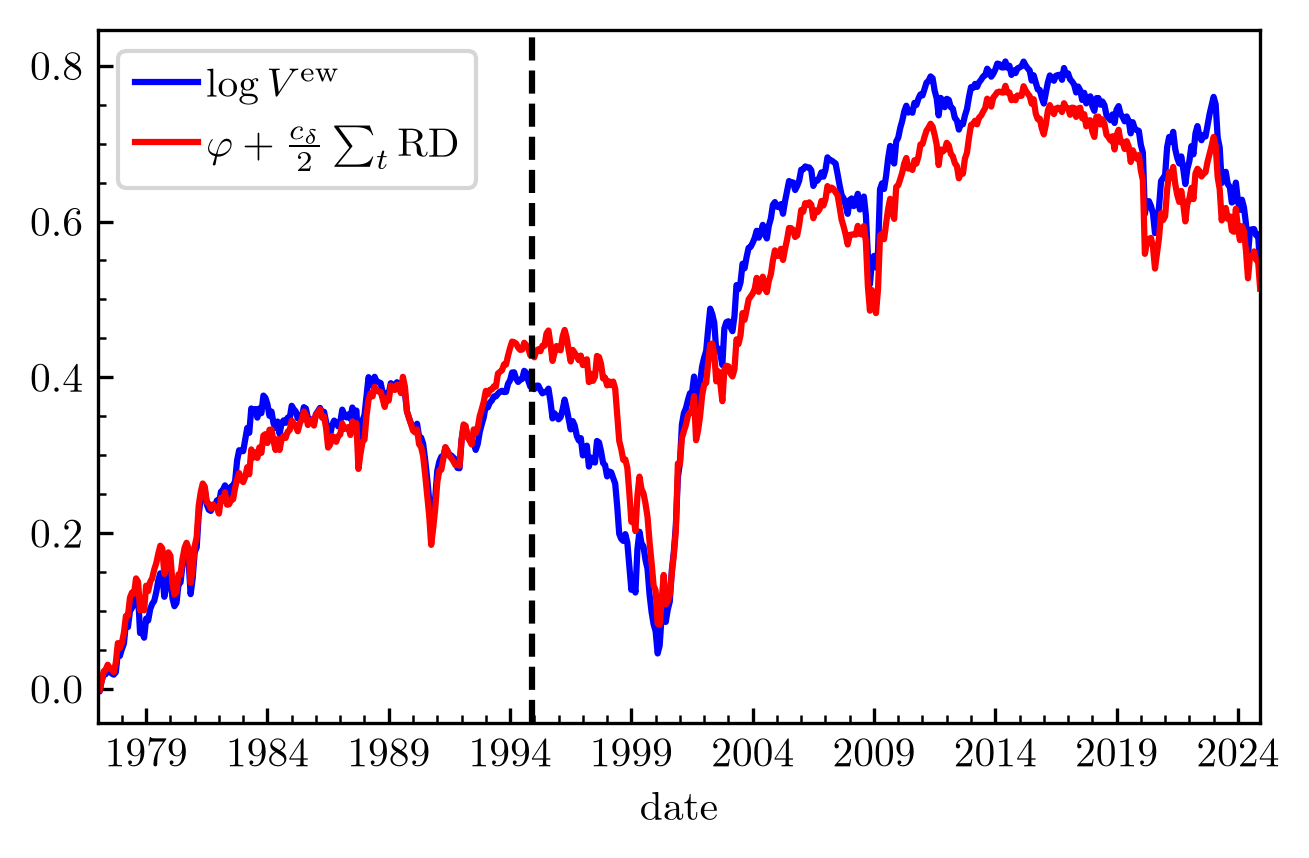

In [9]:
# regression coeffcient c_delta
rd_eql_monthly = signals["rd_eql"].resample("ME").sum() * (DT_DAILY / DT_MONTHLY)

log_ew_ret = np.log1p(monthly_rets.multiply(monthly_eql_wgts.shift(1)).sum(axis=1))
log_mkt_ret = np.log1p(monthly_rets.multiply(monthly_mkt_wgts.shift(1)).sum(axis=1))
log_V_eql = (log_ew_ret - log_mkt_ret).cumsum()

c_delta, fit = calibrate_c_delta(
    diversity_monthly,
    rd_eql_monthly,
    log_V_eql,
    START_DATE,
    WARMUP_END_DATE,
    DT_MONTHLY,
)

fig, ax = plt.subplots(figsize=(width, height))
log_V_eql.plot(ax=ax, color="b", label="$\\log V^{\\mathrm{ew}}$")
fit.plot(
    ax=ax, color="r", label="$\\varphi + \\frac{c_\\delta}{2}\\sum_t \\mathrm{RD}$"
)
ax.axvline(x=pd.Timestamp(WARMUP_END_DATE), color="k", linestyle="--")
ax.legend();

In [10]:
signals["dispersion"] = c_delta * signals["rd_eql"]
signals_path = f"{DATA}/processed/signals_1977.csv"
signals.to_csv(signals_path, index=True)
print(f"Saved signals to {relative_path(signals_path)}")

signals_clean["dispersion"] = c_delta * signals_clean["rd_eql"]
signals_clean_path = f"{DATA}/processed/signals_clean_1977.csv"
signals_clean.to_csv(signals_clean_path, index=True)
print(f"Saved cleaned signals to {relative_path(signals_clean_path)}")

Saved signals to ./data/processed/signals_1977.csv
Saved cleaned signals to ./data/processed/signals_clean_1977.csv
